<a href="https://colab.research.google.com/github/RodrigoCasanova/Backend/blob/main/BIY7121_Entrega_3_G1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación 3: Modelos de clasificacion y segmentacion
**Autores:** Rodrigo Casanova, José Vásquez, Samuel Acuña  
**Correos:** rodr.casanova@duocuc.cl, jo.vasquezp@duocuc.cl, sam.acuna@duocuc.cl  
**Fecha de creación:** Junio 2026  
**Versión:** 1.0

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree

from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.model_selection import train_test_split

## Contexto y objetivo del proyecto

Una empresa de construcción que opera en ciudades como Concepción, Valdivia, Temuco y Punta Arenas busca optimizar la planificación de sus obras considerando las condiciones climáticas.

A partir del análisis de variables como precipitaciones, horas de sol y temperatura, la empresa ajusta sus cronogramas de trabajo para reducir retrasos y mejorar la eficiencia operativa.

## Carga del conjunto de datos

In [ ]:
!wget https://raw.githubusercontent.com/RodrigoCasanova/Mineria_de_datos_grupo1/refs/heads/main/datos/data_clima_2025_final.csv

data = pd.read_csv("data_clima_2025_final.csv", sep=",", low_memory = False)
data.head()

--2026-06-25 01:19:00--  https://raw.githubusercontent.com/RodrigoCasanova/Mineria_de_datos_grupo1/refs/heads/main/datos/data_clima_2025_final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4527300 (4.3M) [text/plain]
Saving to: ‘data_clima_2025_final.csv’

data_clima_2025_fin 100%[===================>]   4.32M  --.-KB/s    in 0.03s   

2026-06-25 01:19:00 (136 MB/s) - ‘data_clima_2025_final.csv’ saved [4527300/4527300]



,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,33024.0,10.644075,5.213359,-5.100000,7.050000,10.400000,13.700000,31.750000
relative_humidity_2m,33024.0,79.042842,16.228987,15.230701,68.349886,82.217838,92.891105,100.000000
apparent_temperature,33024.0,8.337603,6.350746,-8.741941,3.876656,8.232820,12.350445,32.108310
precipitation,33024.0,0.138981,0.582210,0.000000,0.000000,0.000000,0.000000,13.200000
cloud_cover,33024.0,62.114977,41.871036,0.000000,13.000000,88.000000,100.000000,100.000000
wind_speed_10m,33024.0,11.930189,8.474665,0.000000,5.649248,9.940824,15.882896,65.250920
wind_direction_10m,33024.0,205.227225,101.410042,0.367278,139.531913,229.398790,284.036250,360.000000
rain,33024.0,0.136601,0.577866,0.000000,0.000000,0.000000,0.000000,13.200000
is_day,33024.0,0.495882,0.499991,0.000000,0.000000,0.000000,1.000000,1.000000
sunshine_duration,33024.0,1221.216663,1650.360797,0.000000,0.000000,0.000000,3600.000000,3600.000000


In [ ]:
data.shape

(33024, 15)

## Fase 3 - Preparación de Datos

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.isnull().sum()

,0
date,0
temperature_2m,0
relative_humidity_2m,0
apparent_temperature,0
precipitation,0
cloud_cover,0
wind_speed_10m,0
wind_direction_10m,0
rain,0
is_day,0


In [ ]:
for columna in[
    "relative_humidity_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "rain",
    "is_day",
    "sunshine_duration",
    "is_rainy_hour"
]:
  print(f"{columna:<25} tiene {len(data[data[columna] < 0])} valores negativos")

relative_humidity_2m      tiene 0 valores negativos
precipitation             tiene 0 valores negativos
cloud_cover               tiene 0 valores negativos
wind_speed_10m            tiene 0 valores negativos
wind_direction_10m        tiene 0 valores negativos
rain                      tiene 0 valores negativos
is_day                    tiene 0 valores negativos
sunshine_duration         tiene 0 valores negativos
is_rainy_hour             tiene 0 valores negativos


In [ ]:
print("Humedad fuera de rango:",
      len(data[(data["relative_humidity_2m"] < 0) | (data["relative_humidity_2m"] > 100)]))

print("Dirección del viento fuera de rango:",
      len(data[(data["wind_direction_10m"] < 0) | (data["wind_direction_10m"] > 360)]))

print("Nubosidad fuera de rango:",
      len(data[(data["cloud_cover"] < 0) | (data["cloud_cover"] > 100)]))

Humedad fuera de rango: 0
Dirección del viento fuera de rango: 0
Nubosidad fuera de rango: 0


In [ ]:
def tratar_inconsistencias(df):
    df = df.copy()

    # 1. Valores negativos en variables donde no deberían existir
    columnas_no_negativas = [
        "precipitation",
        "rain",
        "cloud_cover",
        "wind_speed_10m",
        "sunshine_duration",
        "relative_humidity_2m"
    ]

    for col in columnas_no_negativas:
        if col in df.columns:
            n = (df[col] < 0).sum()

            if n > 0:
                print(f"{col}: {n} valores negativos reemplazados por NaN")
                df[col] = df[col].where(df[col] >= 0, np.nan)

    # 2. Humedad fuera de rango [0, 100]
    if "relative_humidity_2m" in df.columns:
        mask = (
            (df["relative_humidity_2m"] < 0) |
            (df["relative_humidity_2m"] > 100)
        )

        if mask.sum() > 0:
            print(f"relative_humidity_2m: {mask.sum()} valores fuera de rango reemplazados por NaN")
            df.loc[mask, "relative_humidity_2m"] = np.nan

    # 3. Dirección del viento fuera de rango [0, 360]
    if "wind_direction_10m" in df.columns:
        mask = (
            (df["wind_direction_10m"] < 0) |
            (df["wind_direction_10m"] > 360)
        )

        if mask.sum() > 0:
            print(f"wind_direction_10m: {mask.sum()} valores fuera de rango reemplazados por NaN")
            df.loc[mask, "wind_direction_10m"] = np.nan

    # 4. Nubosidad fuera de rango [0, 100]
    if "cloud_cover" in df.columns:
        mask = (
            (df["cloud_cover"] < 0) |
            (df["cloud_cover"] > 100)
        )

        if mask.sum() > 0:
            print(f"cloud_cover: {mask.sum()} valores fuera de rango reemplazados por NaN")
            df.loc[mask, "cloud_cover"] = np.nan

    # 5. Variables binarias fuera de valores esperados
    for col in ["is_day", "is_rainy_hour"]:
        if col in df.columns:
            mask = ~df[col].isin([0, 1])

            if mask.sum() > 0:
                print(f"{col}: {mask.sum()} valores no binarios reemplazados por NaN")
                df.loc[mask, col] = np.nan

    return df


data = tratar_inconsistencias(data)

### Interpretación:

Se aplicó un tratamiento de inconsistencias considerando reglas propias del contexto climático. Para variables como humedad relativa y nubosidad se validó que sus valores estuvieran entre 0 y 100. Para la dirección del viento se validó el rango entre 0 y 360 grados. Además, se revisó que las variables binarias mantuvieran únicamente los valores 0 y 1.

En caso de encontrar valores fuera de rango, estos fueron reemplazados por NaN para que posteriormente fueran tratados por el imputador definido dentro del pipeline. Esta decisión permite mantener un flujo de preparación consistente y evita eliminar registros completos cuando solo una variable presenta un valor inválido.

No se consideró la temperatura negativa como inconsistencia, ya que en datos meteorológicos puede representar una condición climática real.

## Identificación de valores atípicos

In [ ]:
def buscar_atipicos(data: pd.DataFrame, columna: str) -> pd.DataFrame:
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return data[
        (data[columna] < limite_inferior) |
        (data[columna] > limite_superior)
    ]


def obtener_cantidad_atipicos(data: pd.DataFrame, columnas: list) -> dict:
    total_atipicos = {}

    for columna in columnas:
        atipicos = buscar_atipicos(data, columna)
        total_atipicos[columna] = atipicos.shape[0]

    return total_atipicos

columnas_atipicos = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "rain",
    "sunshine_duration",

]

atipicos_por_columna = obtener_cantidad_atipicos(data, columnas_atipicos)

pd.DataFrame.from_dict(
    atipicos_por_columna,
    orient="index",
    columns=["Cantidad Atípicos"]
)

,Cantidad Atípicos
temperature_2m,476
relative_humidity_2m,130
precipitation,6152
cloud_cover,0
wind_speed_10m,1241
wind_direction_10m,0
rain,6100
sunshine_duration,0


### Interpretación:

Se identificaron valores atípicos mediante el método del rango intercuartílico. Se observan valores extremos principalmente en temperatura, precipitación, lluvia y velocidad del viento.

En este contexto, los valores atípicos no necesariamente representan errores, ya que pueden corresponder a eventos climáticos reales. Por esta razón, no se eliminaron directamente. En su lugar, se aplicará winsorización dentro del pipeline para reducir su impacto sin perder registros del conjunto de datos.

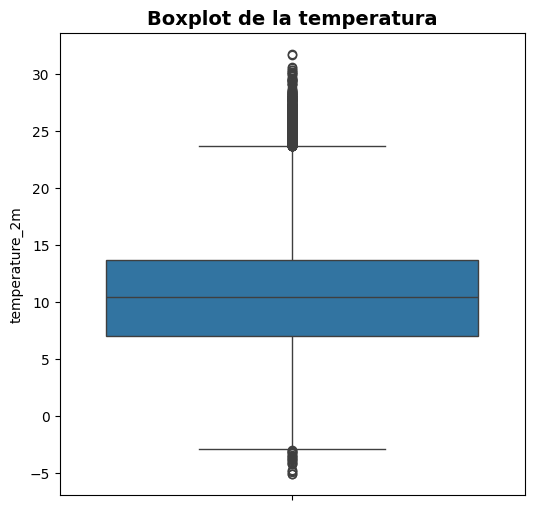

In [ ]:
plt.figure(figsize=(6,6))

sb.boxplot(y=data['temperature_2m'])

plt.title(
    'Boxplot de la temperatura',
    fontsize=14,
    fontweight='bold'
)

plt.show()

## Transformación cíclica de hora y mes

In [ ]:
data["fecha"] = pd.to_datetime(data["date"])

data["hora"] = data["fecha"].dt.hour
data["mes"] = data["fecha"].dt.month

data[["fecha", "hora", "mes"]].head()

,fecha,hora,mes
0,2025-01-01 03:00:00+00:00,3,1
1,2025-01-01 04:00:00+00:00,4,1
2,2025-01-01 05:00:00+00:00,5,1
3,2025-01-01 06:00:00+00:00,6,1
4,2025-01-01 07:00:00+00:00,7,1


In [ ]:
data["hora_sin"] = np.sin(2 * np.pi * data["hora"] / 24)
data["hora_cos"] = np.cos(2 * np.pi * data["hora"] / 24)

data["mes_sin"] = np.sin(2 * np.pi * data["mes"] / 12)
data["mes_cos"] = np.cos(2 * np.pi * data["mes"] / 12)

data[[
    "hora",
    "hora_sin",
    "hora_cos",
    "mes",
    "mes_sin",
    "mes_cos"
]].head()

,hora,hora_sin,hora_cos,mes,mes_sin,mes_cos
0,3,0.707107,7.071068e-01,1,0.5,0.866025
1,4,0.866025,5.000000e-01,1,0.5,0.866025
2,5,0.965926,2.588190e-01,1,0.5,0.866025
3,6,1.000000,6.123234e-17,1,0.5,0.866025
4,7,0.965926,-2.588190e-01,1,0.5,0.866025


## Interpretación:

Se aplicó una transformación cíclica a las variables `hora` y `mes` utilizando funciones seno y coseno.

Esta transformación permite representar correctamente variables temporales con comportamiento circular. Por ejemplo, las 23:00 y las 00:00 son horas cercanas, aunque numéricamente puedan parecer lejanas. Lo mismo ocurre entre diciembre y enero.

De esta manera, el modelo puede interpretar de mejor forma los ciclos diarios y estacionales presentes en los datos.

In [ ]:
target = "is_rainy_hour"

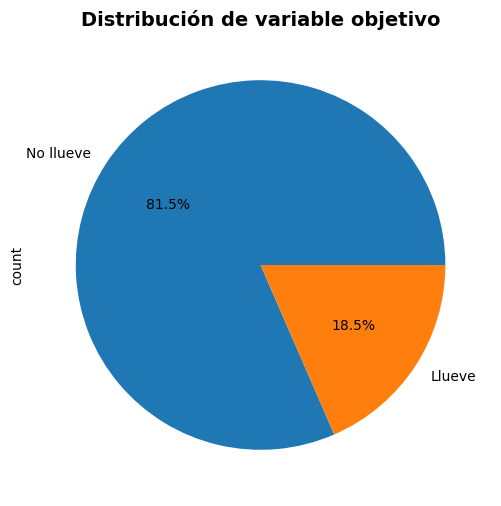

In [ ]:
# Revisa la distribución de la variable objetivo
# En este caso se obtiene un gráfico de torta
data[target].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['No llueve', 'Llueve'],
                                 figsize=(6, 6))
plt.title("Distribución de variable objetivo", fontsize=14, fontweight="bold")
plt.show()


In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [ ]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

In [ ]:
# Preprocesamiento numérico: imputación con media + estandarización
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [ ]:
correlaciones = data.corr(numeric_only=True)

correlacion_objetivo = correlaciones["is_rainy_hour"].sort_values(
    ascending=False
)

correlacion_objetivo



,is_rainy_hour
is_rainy_hour,1.000000
precipitation,0.498582
rain,0.496635
cloud_cover,0.327969
relative_humidity_2m,0.245598
wind_speed_10m,0.186934
mes,0.057468
hora,0.036388
longitud,0.029535
is_day,0.027955


In [ ]:
data.describe().columns

Index(['temperature_2m', 'relative_humidity_2m', 'apparent_temperature',
       'precipitation', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m',
       'rain', 'is_day', 'sunshine_duration', 'latitud', 'longitud',
       'is_rainy_hour', 'hora', 'mes', 'hora_sin', 'hora_cos', 'mes_sin',
       'mes_cos'],
      dtype='object')

In [ ]:
features_num = [
    "cloud_cover",
    "relative_humidity_2m",
    "wind_speed_10m",
    "sunshine_duration",
    "temperature_2m",
    "is_day",
    "hora_sin",
    "hora_cos",
    "mes_sin",
    "mes_cos"
]
features_cat = [
    "Localidad",

]